## Replication of the micrograd package made by Andrej Karpathy from scratch
Video by Andrej: https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=1

This notebook mainly serves the purpose of building and improving my own understanding of neural nets and backprop. Therefore it will include a lot of markdown sections with my unpolished comments and notes that serve my personal learning. In case you are intersted in the code I recommend visiting Andrej's repo: https://github.com/karpathy/micrograd

Micrograd is operating on an excessive granularity, calculating the gradient note by note. In prod we use n-dimensional tensors for efficiency. But non of the math changes.

In [1]:
#basic imports
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

#### Part 1: Understanding gradient descent
1.1 Reworking derivatives (cause high school is a long time ago)

In [2]:
# arbitrary mathematical function
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

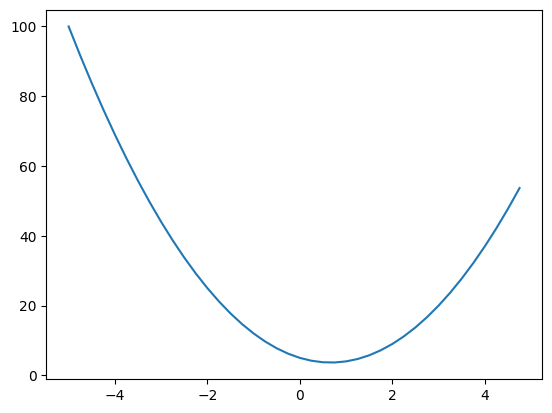

In [4]:

xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

Defintion of a derivative: If you slightly bump up x by a small number h -> how does the funtion respond? Does it go up or down? 

So we take the difference between f(x + h) and f(x) and normalize by the bump we gave (h). Making h very very small lets us approximate the actual slope at that point.

In [5]:
h = 0.000000001
x = 3
(f(x + h) - f(x)) / h

14.000001158365194

or using high school math derivative rules: f = 3x^2 - 4x + 5 -> f' = 6x -4 --> f'(3) = 6*3 - 4 ---> 14

In [6]:
# let's get a bit more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0000001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
# difference through bump and normalized by h
print('slope', (d2 - d1)/h)


d1 4.0
d2 4.000000099999999
slope 0.999999993922529


In [8]:
# creating a value wrapper to store values as python objects

class Value: 
    
    def __init__(self, data, _children=(), _op='', label='empty'):
        self.data = data
        # storing the children values if a new Value class object is created through __add__ or __mul_
        self._prev = set(_children)
        # storing which operation was used to create the new Value class object
        self._op = _op
        self.label = label
        # creating an attribute that holds the gradient of that Value object
        # it represents the derivative of the output L with respect to the Value object
        self.grad = 0.0
        # Of course doing the backprop manually is horribly inefficient, therefore lets automate the backward pass
        self._backward = lambda: None
    
    #printing out the value not the appointed memory space 
    def __repr__(self):
        return f"Value(data={self.data})"
    
    #using python dunder methods to make the Value object usable for arithmatic operations 
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
            
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1) / (math.exp(2*x) +1 ) 
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [ ]:
a = Value(2)
b = Value(3)

a + b



Value(data=5)

In [10]:
# initial example asigning some values 
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
a * b + c
#(a.__mul__(b)).__add__(c)

d = e + c; d.label='d'

f = Value(-2.0, label='f')
L = d * f; L.label='L'
L


Value(data=-8.0)

In [11]:
print(d._prev)
print(d._op)

{Value(data=-6.0), Value(data=10.0)}
+


Next we use graphviz to visualize how we arrive at any given Value object

In [12]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape = "record")
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot
            

In [13]:
L.grad = 1.0

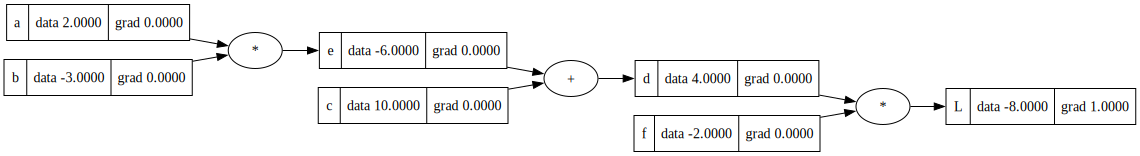

In [14]:
draw_dot(L)

Finding the derivative of L with respect to d 
L = d * f 
What is the derivative of L with respect to d:
dL / dd =? f
Defined as:
(f(x+h)-f(x))/h : h lim --> 0
==
((d+h)*f - d*f)/h
-> (d*f + h*f - d*f) / h
--> (h*f) / h
---> f

Symmetrically the derivative of L with respect to f 
L = f * d  
What is the derivative of L with respect to f:
dL / df =? d
Defined as:
(f(x+h)-f(x))/h : h lim --> 0
==
((f+h)*d - f*d)/h
-> (f*d + h*d - f*d) / h
--> (h*d) / h
---> d

Following the crux and most complex part of backpropogation: 
Finding the derivative of L with respect to c:
dL / dc =? 
We know how d and f directly influence L. But how do we find out how bumping c in one direction influences L through d?

So we first find the derivative of d with respect to c:
dd / dc =? 1.0 

d = c + e 
back to the definition of a derivative: 
(f(x+h)-f(x))/h : h lim --> 0

focusing on c and its effect on d:
((c+h + e) - (c + e)) / h
(c + h + e - c - e) / h = h/h = 1.0

So by symmetry dd / de = 1.0 as well

--> Those are the local derivatives. Refering to the derivative at just the plus note (how bumping up c influences d). The local derivative does not know anything about the rest of the graph that it is embedded in. All it knows is that it is a plus node -> it took c + e and created d 

How do can we know how dL / dc ? --> through the chain rule
It tells us how we can derivatives together. https://en.wikipedia.org/wiki/Chain_rule#:~:text=substitution%20rule.-,Intuitive%20explanation,-%5Bedit%5D
-> If a car travels twice as fast as the bicycle and the bicycle is four times faster as a walking man, then the car travels 2 * 4 = 8 times faster than the man.

WANT:
dL / dc = (dL / dd ) * (dd / dc)

KNOW:
dL / dd 
dd / dc

A plus node just routes the derivative through the intermediate steps, since its local derivative is just 1.0. Therefore the dL / dd value stays constant.

dL / de = -2.0 
dL / da = (dL / de) * (de / da) = -2.0 * -3.0 = 6.0
So a times node just knows that it produced an e node by mulitplying a and b nodes. So the local gradients are: 
de / da = b
de / db = a

In [15]:
# the derivatives of L in respect to:
a.grad = -2.0*-3.0
b.grad = -2.0 * 2.0 

d.grad = -2.0
f.grad = 4.0

c.grad = -2.0 * 1.0
e.grad = -2.0 * 1.0


In [16]:
# staging area for local experiments
def lol():
    
    h = 0.0000001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    a * b + c
    #(a.__mul__(b)).__add__(c)

    d = e + c; d.label='d'

    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data
    
    # measuring the derivative of L with respect to a
    a = Value(2.0, label='a')
    # a.data += h
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    #e.data += h
    a * b + c
    #(a.__mul__(b)).__add__(c)

    d = e + c; d.label='d'
    #d.data += h
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data
    
    print((L2 - L1)/ h)
    
lol()

-3.9999999934536845


In [17]:
# lets try it and nudge our L to go up
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad 
f.data += 0.01 * f.grad 

# if we nudge in the direction of the gradient L should go up 
# doing the forward pass:
e = a * b
d = e + c
L = d * f

print(L.data)
# this is essentially one learning / optimazition step


-7.286496


Next we are doing one more useful example of backprop, by backproping through a neuron: 

In [18]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights of the neuron
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron 
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b in small steps
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*x2 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'out'


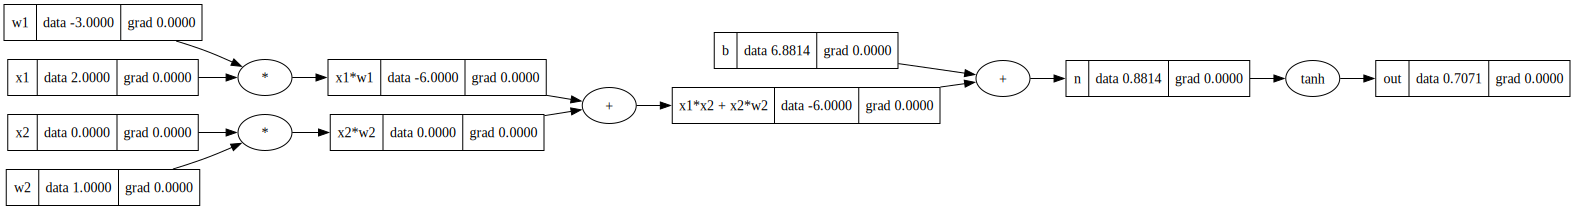

In [19]:
draw_dot(o)

### Below manually finding the gradients:

In [20]:
o.grad = 1.0

In [21]:
1- o.data**2

0.4999999999999999

First we need to find the derivative of o = tanh(n). 
Consulting wikipedia.org:
do / dn = 1 - o**2

In [22]:
n.grad = 0.5
# according to our observation that the gradient just flows through + nodes, we can say that:
x1w1x2w2.grad = 0.5
b.grad = 0.5
# another layer of plus
x1w1.grad = 0.5
x2w2.grad = 0.5

#next we are looking for the grads of x2 and w2. Both are connected to x2w2 through a multiplication operation
#for x2 we recall that according to chain rule the gradient in this case will be the product of the derivative of o in respect to x2*w2 and the derivative of o in respect to x2, which is just w2, so 
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
# This particular with w2.grad == 0 is an interesting example. Since x2.data == 0 it does not matter how much we bump up w2. The multiplication with x2.data == 0 makes the derivative also 0
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

### Below using the _backward method to find the gradients:

In [23]:
# have to be careful though, because self.grad was initialized as 0.0. So we need to manually intialize it at 1.0 for the output
o.grad = 1.0

In [24]:
o._backward()

In [25]:
n._backward()

In [26]:
x1w1x2w2._backward()

In [27]:
x1w1._backward()
x2w2._backward()

So the last step is to call the _backward method in the correct order. This ordering can be achieved via topological sort

In [28]:
# calling all nodes in backwards order
o.grad = 1.0
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

In [29]:
#calling backprop with the class method
o.backward()

The current build in the video runs into a tricky bug exampled below: 
What happens is that self and other are the same object in that case. The reason for this is that the grad is overwritten. So instead of setting the gradients we need to accumulate them.

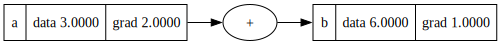

In [30]:
# before fixing this the a grad shows 1 instead of 2, which is of course incorrect.
a = Value(3.0, label='a')
b = a + a ; b.label='b'
b.backward()
draw_dot(b)

Andrej cleans out his nb at 1:27 in the video. I keep the intermediate steps to keep track of progress

Next step is to integrate all the operations to perform tanH manually

In [31]:
# initializing an updated version of the Value class

class Value: 
    
    def __init__(self, data, _children=(), _op='', label='empty'):
        self.data = data
        # storing the children values if a new Value class object is created through __add__ or __mul_
        self._prev = set(_children)
        # storing which operation was used to create the new Value class object
        self._op = _op
        self.label = label
        # creating an attribute that holds the gradient of that Value object
        # it represents the derivative of the output L with respect to the Value object
        self.grad = 0.0
        # Of course doing the backprop manually is horribly inefficient, therefore lets automate the backward pass
        self._backward = lambda: None
    
    #printing out the value not the appointed memory space 
    def __repr__(self):
        return f"Value(data={self.data})"
    
    #using python dunder methods to make the Value object usable for arithmatic operations 
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other - 1) * out.grad
        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self + other

    def __rmul__(self, other): # other * self
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1) / (math.exp(2*x) +1 ) 
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [32]:
# a + 1 currently not working since in the Value class __add__ calls other.data, and int object does not have a data attribute
# after adding a line 'other = other if isinstance(other, Value) else Value(other)' we can wrap an integer as Value object and use our __add__ method
a = Value(2.0)
a + 1
# same for __mul__:
a * 2
a.__mul__(2)
# 2 * a does not work since python will do 
# 2 * a
# which is the equivalent of 2.__mul__(a), which of course does not work
# for this reason we integrate __rmul__ in our class object. Now it should work
2 * a

Value(data=4.0)

In [33]:
# next we implement division -> but division a/b can be expressed as a * (1/b), which is the same as a * (b**-1). Therefore we can focus on implementing taking our self.data to a constant power.
a = Value(2.0)
b = Value(4.0)
a / b

Value(data=0.5)

In [34]:
# next substraction - straight forward negated addition
a - b

Value(data=-2.0)

Rebuilding the neuron with manual tanh

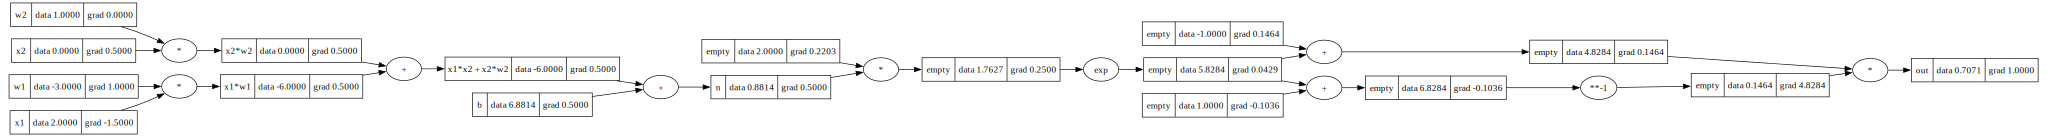

In [35]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights of the neuron
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron 
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b in small steps
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*x2 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# --- 
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ---
o.label = 'out'
o.backward()
draw_dot(o)

In [36]:
# equivalent using pytorch
import torch

x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]). double()              ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

ModuleNotFoundError: No module named 'torch'

Starting to build out a neural net :D

In [ ]:
# creating a neuron class 
class Neuron:
    
    def __init__(self, nin): #number of input weights
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b 
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self): # creating a list of all the neurons params
        return self.w + [self.b] # self.w is a list -> list plus list just gives you a list
    
class Layer:
    def __init__(self, nin, nout): #nout is number of outputs -> how many neurons does the layer hold
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self, nin, nouts): 
        sz = [nin] + nouts # size is n in plus n of outputs
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

#creating an MLP with three dimensional input 2 hidden layers with four neurons each and one output neuron  
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.346424320984666)

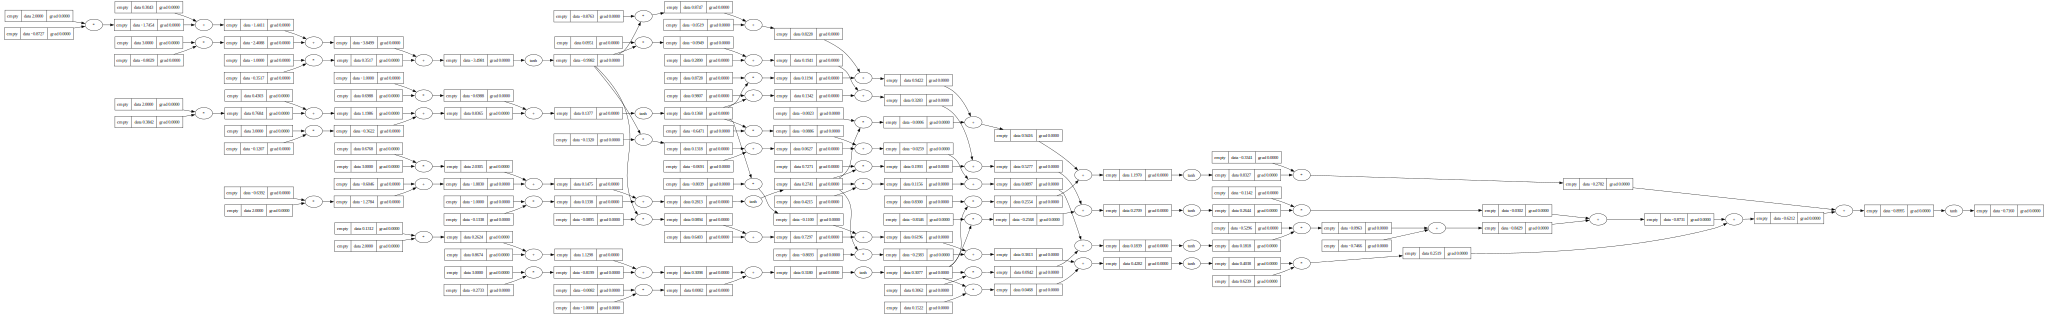

In [ ]:
draw_dot(n(x))

In [ ]:
# example dataset
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ypred = [n(x) for x in xs] # getting the current predictions of the neural net
ypred

[Value(data=-0.5544401311899452),
 Value(data=-0.526217625358783),
 Value(data=-0.4315766131612023),
 Value(data=-0.4336163190390765)]

In [ ]:
# calculating the loss as a single number by getting the mean squared error for each ypred
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=0.9585903334768524)

In [ ]:
loss.backward()

In [ ]:
# looking at the gradient for loss with respect to the first layer first neuron first weight -> since it is negative, bumping up the weight will bring down the loss
print(n.layers[1].neurons[1].w[1].grad)
# looking at its data
print(n.layers[1].neurons[1].w[1].data)

-1.761184229451187
-0.12902383720077004


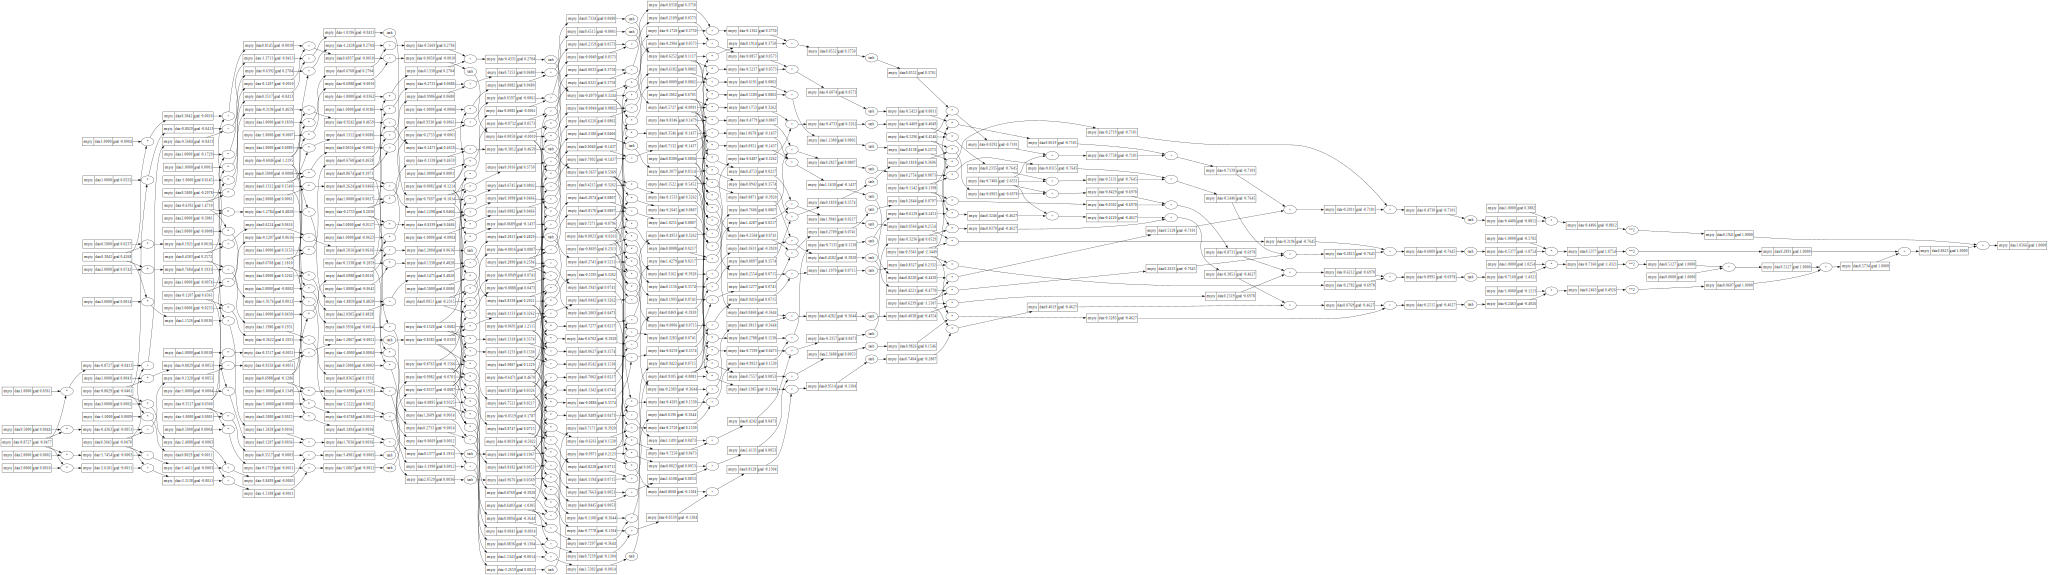

In [ ]:
# four forward passes and their backward pass:
draw_dot(loss)

In [ ]:
# getting all params from our network n
len(n.parameters())

41

In [ ]:
# creating the mechanism for one epoch
for p in n.parameters():
    p.data += -0.01 * p.grad

In [ ]:
# looking at value and gradient again:
print(n.layers[1].neurons[1].w[1].grad)
# looking at its data
print(n.layers[1].neurons[1].w[1].data)

-1.761184229451187
-0.11141199490625817


In [ ]:
# recalculating the (smaller) loss
ypred = [n(x) for x in xs] # getting the current predictions of the neural net
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=5.702356678753134)

In [ ]:
# zero gradients 
for p in n.parameters():
    p.grad = 0.0

In [ ]:
# recalculating the (smaller) loss
ypred = [n(x) for x in xs] # getting the current predictions of the neural net
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=0.03295169318898309)

In [ ]:
loss.backward()

In [ ]:
# creating the mechanism for one epoch
for p in n.parameters():
    p.data += -0.01 * p.grad

In [ ]:
ypred

[Value(data=0.9464087818903755),
 Value(data=-0.9167470196896869),
 Value(data=-0.9108136494394053),
 Value(data=0.8767343897364595)]

In [ ]:
# looking at value and gradient again:
print(n.layers[1].neurons[1].w[1].grad)
# looking at its data
print(n.layers[1].neurons[1].w[1].data)

0.04965267930685124
-0.669924777523898


In [ ]:
#new net 
x = [2.0, 3.0, -1.0]
new_n = MLP(3, [4, 4, 1])

# training loop
for k in range(10):

    # forward pass
    ypred = [new_n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

    #zeroing gradients
    for p in new_n.parameters():
        p.grad = 0.0

    #backward pass 
    loss.backward()

    #update 
    for p in new_n.parameters():
        p.data += 0.05 * -p.grad

    print(k, loss.data)

print(ypred)

0 5.62088261818065
1 2.9573111872256543
2 1.8952398713191678
3 0.8782173415992722
4 0.5127337785539235
5 0.3637118209049809
6 0.27910455627242675
7 0.22438212761734852
8 0.18641038793321443
9 0.1586964116024862
[Value(data=0.8057111389451592), Value(data=-0.8274738668949425), Value(data=-0.7896494895062957), Value(data=0.7833536379180279)]
